In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv('../dados/processed/ppm_tratado.csv')
df.head()

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,tipo_rebanho_codigo,tipo_rebanho_nome,valor,valor_is_inibido
0,N1,Brasil,1,Brasil,2003,2003,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,195551576.0,0
1,N1,Brasil,1,Brasil,2004,2004,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,204512737.0,0
2,N1,Brasil,1,Brasil,2005,2005,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,207156696.0,0
3,N1,Brasil,1,Brasil,2006,2006,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,205886244.0,0
4,N1,Brasil,1,Brasil,2007,2007,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,199752014.0,0


Como são os dados brutos do PPM?

In [3]:
colunas_codigo = [c for c in df.columns if c.endswith('_codigo')]
df_nome = df.drop(columns=colunas_codigo)
df_nome.head()

,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,tipo_rebanho_nome,valor,valor_is_inibido
0,Brasil,Brasil,2003,Efetivo dos rebanhos,Cabeças,Bovino,195551576.0,0
1,Brasil,Brasil,2004,Efetivo dos rebanhos,Cabeças,Bovino,204512737.0,0
2,Brasil,Brasil,2005,Efetivo dos rebanhos,Cabeças,Bovino,207156696.0,0
3,Brasil,Brasil,2006,Efetivo dos rebanhos,Cabeças,Bovino,205886244.0,0
4,Brasil,Brasil,2007,Efetivo dos rebanhos,Cabeças,Bovino,199752014.0,0


Como ficam os dados sem as colunas de código?

**Regra importante (não somar espécies):** bovinos, caprinos, ovinos, suínos e galináceos são medidos em "Cabeças", mas não são unidades equivalentes entre si — uma cabeça de boi e uma de galinha não têm o mesmo peso econômico ou biológico. Por isso, em nenhum momento desta análise somamos `tipo_rebanho_nome` entre si (não existe "rebanho total"). Toda agregação (Brasil, Ceará, participação %, municípios) é feita **dentro de uma mesma espécie**.

In [4]:
df_nome.groupby('tipo_rebanho_nome')['valor'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_rebanho_nome,,,,,,,,
Bovino,4092.0,1.177824e+06,1.567574e+07,149.0,4662.50,9220.5,17510.25,2.386209e+08
Caprino,4092.0,6.712919e+04,7.687970e+05,45.0,1181.75,3023.5,6281.00,1.329284e+07
Galináceos - total,4092.0,7.265844e+06,9.580027e+07,1945.0,25691.25,46785.0,105218.00,1.581216e+09
Ovino,4092.0,1.210059e+05,1.341453e+06,0.0,1986.75,5629.5,14493.25,2.186233e+07
Suíno - total,4092.0,2.217075e+05,2.854331e+06,83.0,2613.75,4493.0,7845.25,4.438835e+07


Como se distribui o efetivo (em cabeças) de cada espécie?

In [5]:
print("Valores nulos:", df_nome['valor'].isna().sum())
print("Valores inibidos (sigilo do IBGE):", df_nome['valor_is_inibido'].sum())
print("Linhas duplicadas:", df_nome.duplicated().sum())

Valores nulos: 0
Valores inibidos (sigilo do IBGE): 0
Linhas duplicadas: 0


Os dados têm valores nulos, inibidos ou duplicados?

In [6]:
territorios = df_nome['territorio_nome'].unique()
print(len(territorios))
print(territorios)

186
['Brasil' 'Ceará' 'Abaiara - CE' 'Acarape - CE' 'Acaraú - CE'
 'Acopiara - CE' 'Aiuaba - CE' 'Alcântaras - CE' 'Altaneira - CE'
 'Alto Santo - CE' 'Amontada - CE' 'Antonina do Norte - CE'
 'Apuiarés - CE' 'Aquiraz - CE' 'Aracati - CE' 'Aracoiaba - CE'
 'Ararendá - CE' 'Araripe - CE' 'Aratuba - CE' 'Arneiroz - CE'
 'Assaré - CE' 'Aurora - CE' 'Baixio - CE' 'Banabuiú - CE' 'Barbalha - CE'
 'Barreira - CE' 'Barro - CE' 'Barroquinha - CE' 'Baturité - CE'
 'Beberibe - CE' 'Bela Cruz - CE' 'Boa Viagem - CE' 'Brejo Santo - CE'
 'Camocim - CE' 'Campos Sales - CE' 'Canindé - CE' 'Capistrano - CE'
 'Caridade - CE' 'Cariré - CE' 'Caririaçu - CE' 'Cariús - CE'
 'Carnaubal - CE' 'Cascavel - CE' 'Catarina - CE' 'Catunda - CE'
 'Caucaia - CE' 'Cedro - CE' 'Chaval - CE' 'Choró - CE' 'Chorozinho - CE'
 'Coreaú - CE' 'Crateús - CE' 'Crato - CE' 'Croatá - CE' 'Cruz - CE'
 'Deputado Irapuan Pinheiro - CE' 'Ereré - CE' 'Eusébio - CE'
 'Farias Brito - CE' 'Forquilha - CE' 'Fortaleza - CE' 'Fortim - CE'


Quantos e quais territórios temos no PPM?

In [7]:
anos = df_nome['ano_nome'].unique()
print(len(anos))
print(anos)

22
[2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


Quantos e quais anos o PPM cobre?

In [8]:
variaveis = df_nome['variavel_nome'].unique()
print(len(variaveis))
print(variaveis)

1
['Efetivo dos rebanhos']


Quais variáveis o PPM mede?

In [9]:
unidades = df_nome['unidade'].unique()
print(len(unidades))
print(unidades)

1
['Cabeças']


Em qual unidade essa variável é medida?

In [10]:
especies = df_nome['tipo_rebanho_nome'].unique()
print(len(especies))
print(especies)

5
['Bovino' 'Caprino' 'Ovino' 'Suíno - total' 'Galináceos - total']


Quais espécies de rebanho o PPM cobre?

## Bovino

Como evoluiu o efetivo de bovino no Brasil e no Ceará?

In [11]:
projecao_bovino_brasil = df_nome[(df_nome['tipo_rebanho_nome'] == 'Bovino') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_bovino_brasil

tipo_rebanho_nome,Bovino
ano_nome,
2003,195551576.0
2004,204512737.0
2005,207156696.0
2006,205886244.0
2007,199752014.0
2008,202306731.0
2009,205307954.0
2010,209541109.0
2011,212815311.0


In [12]:
projecao_bovino_ceara = df_nome[(df_nome['tipo_rebanho_nome'] == 'Bovino') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_bovino_ceara

tipo_rebanho_nome,Bovino
ano_nome,
2003,2254262.0
2004,2269567.0
2005,2299233.0
2006,2352589.0
2007,2424290.0
2008,2460523.0
2009,2494482.0
2010,2546134.0
2011,2614604.0


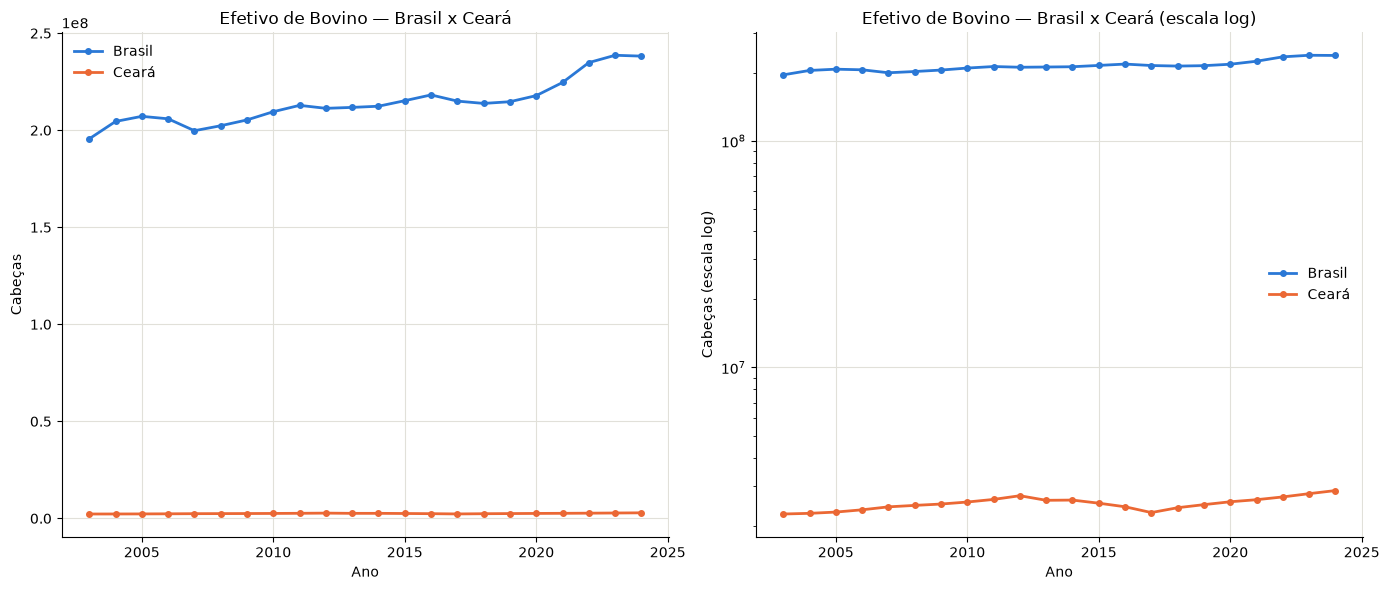

In [13]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}
series_bovino = {"Brasil": projecao_bovino_brasil['Bovino'], "Ceará": projecao_bovino_ceara['Bovino']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for territorio, cor in cores.items():
    serie = series_bovino[territorio]
    ax1.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax2.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax1.set_title("Efetivo de Bovino — Brasil x Ceará")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Cabeças")
ax1.grid(True, color="#e1e0d9", linewidth=0.8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

ax2.set_yscale("log")
ax2.set_title("Efetivo de Bovino — Brasil x Ceará (escala log)")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Cabeças (escala log)")
ax2.grid(True, color="#e1e0d9", linewidth=0.8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [14]:
print(projecao_bovino_brasil)
print()
print(projecao_bovino_ceara)

tipo_rebanho_nome       Bovino
ano_nome                      
2003               195551576.0
2004               204512737.0
2005               207156696.0
2006               205886244.0
2007               199752014.0
2008               202306731.0
2009               205307954.0
2010               209541109.0
2011               212815311.0
2012               211279082.0
2013               211764292.0
2014               212366132.0
2015               215220508.0
2016               218190768.0
2017               215003578.0
2018               213809445.0
2019               214689984.0
2020               217836282.0
2021               224601992.0
2022               234851536.0
2023               238620910.0
2024               238180757.0

tipo_rebanho_nome     Bovino
ano_nome                    
2003               2254262.0
2004               2269567.0
2005               2299233.0
2006               2352589.0
2007               2424290.0
2008               2460523.0
2009               2494

## Caprino

Como evoluiu o efetivo de caprino no Brasil e no Ceará?

In [15]:
projecao_caprino_brasil = df_nome[(df_nome['tipo_rebanho_nome'] == 'Caprino') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_caprino_brasil

tipo_rebanho_nome,Caprino
ano_nome,
2003,9581653.0
2004,10046888.0
2005,10306722.0
2006,10401449.0
2007,9450312.0
2008,9355014.0
2009,9163560.0
2010,9312784.0
2011,9386316.0


In [16]:
projecao_caprino_ceara = df_nome[(df_nome['tipo_rebanho_nome'] == 'Caprino') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_caprino_ceara

tipo_rebanho_nome,Caprino
ano_nome,
2003,869045.0
2004,904258.0
2005,931634.0
2006,946715.0
2007,976880.0
2008,998787.0
2009,1015927.0
2010,1024594.0
2011,1044998.0


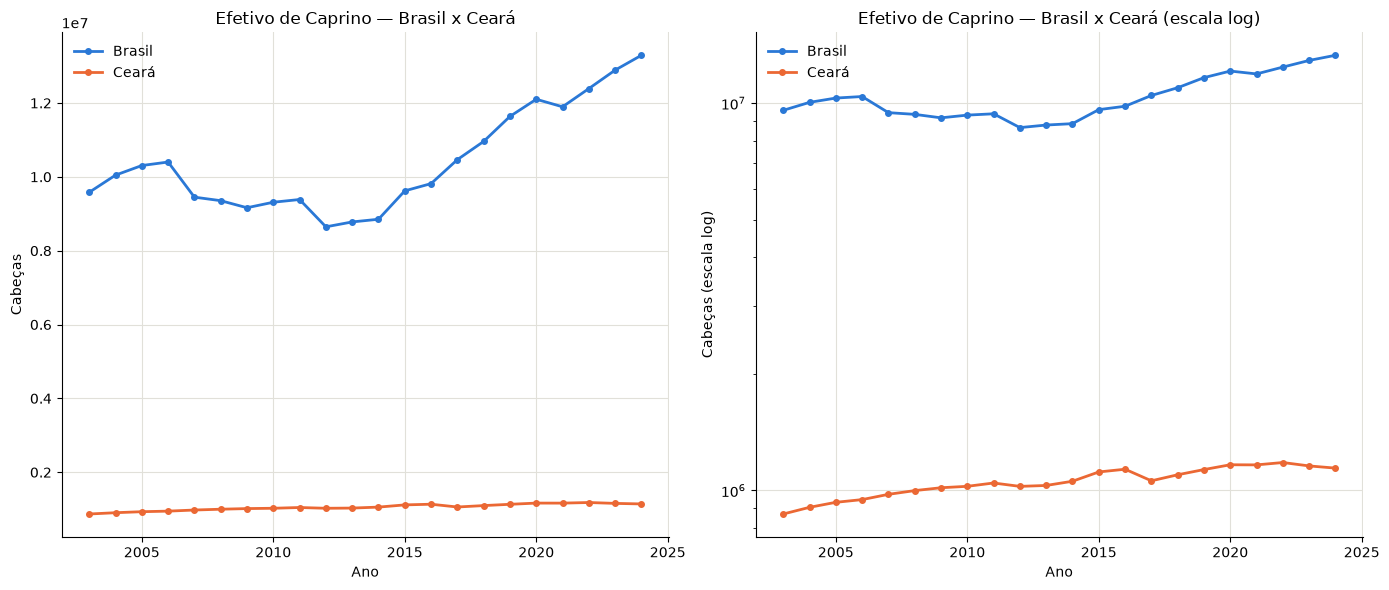

In [17]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}
series_caprino = {"Brasil": projecao_caprino_brasil['Caprino'], "Ceará": projecao_caprino_ceara['Caprino']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for territorio, cor in cores.items():
    serie = series_caprino[territorio]
    ax1.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax2.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax1.set_title("Efetivo de Caprino — Brasil x Ceará")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Cabeças")
ax1.grid(True, color="#e1e0d9", linewidth=0.8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

ax2.set_yscale("log")
ax2.set_title("Efetivo de Caprino — Brasil x Ceará (escala log)")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Cabeças (escala log)")
ax2.grid(True, color="#e1e0d9", linewidth=0.8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [18]:
print(projecao_caprino_brasil)
print()
print(projecao_caprino_ceara)

tipo_rebanho_nome     Caprino
ano_nome                     
2003                9581653.0
2004               10046888.0
2005               10306722.0
2006               10401449.0
2007                9450312.0
2008                9355014.0
2009                9163560.0
2010                9312784.0
2011                9386316.0
2012                8646463.0
2013                8779213.0
2014                8851879.0
2015                9620877.0
2016                9817007.0
2017               10466257.0
2018               10959694.0
2019               11637329.0
2020               12101686.0
2021               11897204.0
2022               12390490.0
2023               12891233.0
2024               13292844.0

tipo_rebanho_nome    Caprino
ano_nome                    
2003                869045.0
2004                904258.0
2005                931634.0
2006                946715.0
2007                976880.0
2008                998787.0
2009               1015927.0
2010              

## Ovino

Como evoluiu o efetivo de ovino no Brasil e no Ceará?

In [19]:
projecao_ovino_brasil = df_nome[(df_nome['tipo_rebanho_nome'] == 'Ovino') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_ovino_brasil

tipo_rebanho_nome,Ovino
ano_nome,
2003,14556484.0
2004,15057838.0
2005,15588041.0
2006,16019170.0
2007,16239455.0
2008,16630408.0
2009,16811721.0
2010,17380581.0
2011,17668063.0


In [20]:
projecao_ovino_ceara = df_nome[(df_nome['tipo_rebanho_nome'] == 'Ovino') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_ovino_ceara

tipo_rebanho_nome,Ovino
ano_nome,
2003,1781951.0
2004,1852448.0
2005,1909182.0
2006,1961724.0
2007,1998165.0
2008,2030982.0
2009,2071098.0
2010,2098893.0
2011,2142567.0


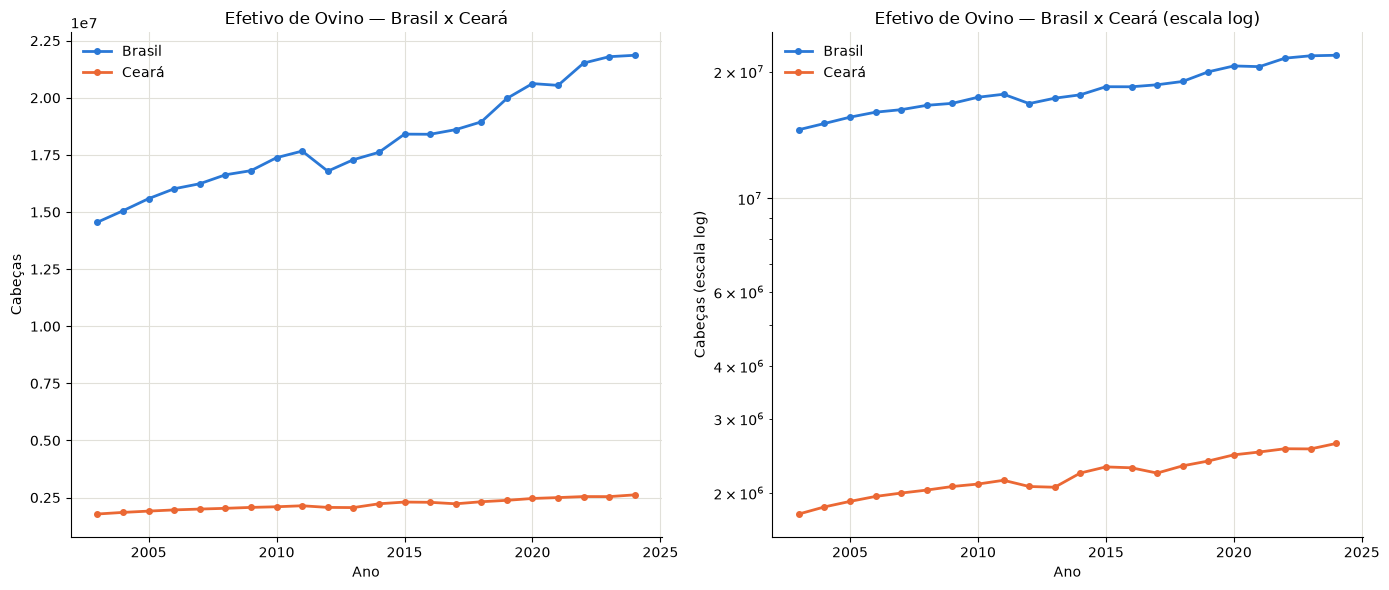

In [21]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}
series_ovino = {"Brasil": projecao_ovino_brasil['Ovino'], "Ceará": projecao_ovino_ceara['Ovino']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for territorio, cor in cores.items():
    serie = series_ovino[territorio]
    ax1.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax2.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax1.set_title("Efetivo de Ovino — Brasil x Ceará")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Cabeças")
ax1.grid(True, color="#e1e0d9", linewidth=0.8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

ax2.set_yscale("log")
ax2.set_title("Efetivo de Ovino — Brasil x Ceará (escala log)")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Cabeças (escala log)")
ax2.grid(True, color="#e1e0d9", linewidth=0.8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [22]:
print(projecao_ovino_brasil)
print()
print(projecao_ovino_ceara)

tipo_rebanho_nome       Ovino
ano_nome                     
2003               14556484.0
2004               15057838.0
2005               15588041.0
2006               16019170.0
2007               16239455.0
2008               16630408.0
2009               16811721.0
2010               17380581.0
2011               17668063.0
2012               16789492.0
2013               17290519.0
2014               17614454.0
2015               18410551.0
2016               18403947.0
2017               18606767.0
2018               18947352.0
2019               19971802.0
2020               20623064.0
2021               20544899.0
2022               21520872.0
2023               21799960.0
2024               21862326.0

tipo_rebanho_nome      Ovino
ano_nome                    
2003               1781951.0
2004               1852448.0
2005               1909182.0
2006               1961724.0
2007               1998165.0
2008               2030982.0
2009               2071098.0
2010              

## Suíno

Como evoluiu o efetivo de suíno no Brasil e no Ceará?

In [23]:
projecao_suino_brasil = df_nome[(df_nome['tipo_rebanho_nome'] == 'Suíno - total') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_suino_brasil

tipo_rebanho_nome,Suíno - total
ano_nome,
2003,32304905.0
2004,33085299.0
2005,34063934.0
2006,35173824.0
2007,35945015.0
2008,36819017.0
2009,38045454.0
2010,38956758.0
2011,39307336.0


In [24]:
projecao_suino_ceara = df_nome[(df_nome['tipo_rebanho_nome'] == 'Suíno - total') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_suino_ceara

tipo_rebanho_nome,Suíno - total
ano_nome,
2003,1067314.0
2004,1082993.0
2005,1089530.0
2006,1101360.0
2007,1132673.0
2008,1152598.0
2009,1160410.0
2010,1167731.0
2011,1193630.0


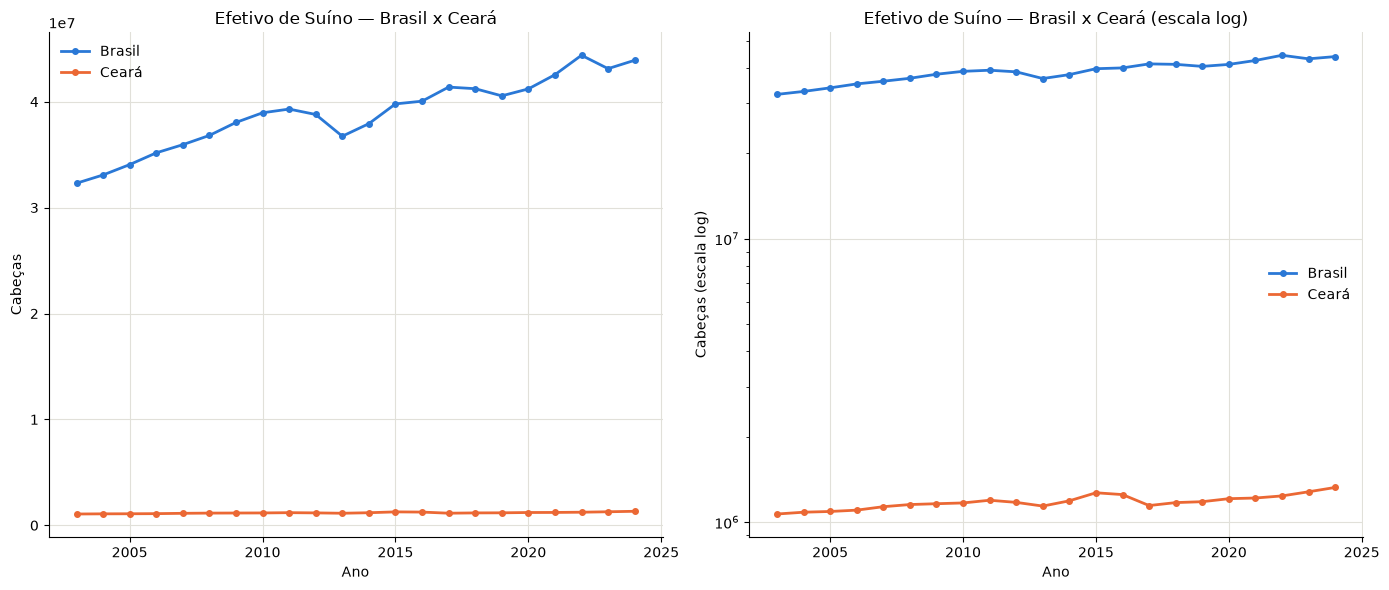

In [25]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}
series_suino = {"Brasil": projecao_suino_brasil['Suíno - total'], "Ceará": projecao_suino_ceara['Suíno - total']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for territorio, cor in cores.items():
    serie = series_suino[territorio]
    ax1.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax2.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax1.set_title("Efetivo de Suíno — Brasil x Ceará")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Cabeças")
ax1.grid(True, color="#e1e0d9", linewidth=0.8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

ax2.set_yscale("log")
ax2.set_title("Efetivo de Suíno — Brasil x Ceará (escala log)")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Cabeças (escala log)")
ax2.grid(True, color="#e1e0d9", linewidth=0.8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [26]:
print(projecao_suino_brasil)
print()
print(projecao_suino_ceara)

tipo_rebanho_nome  Suíno - total
ano_nome                        
2003                  32304905.0
2004                  33085299.0
2005                  34063934.0
2006                  35173824.0
2007                  35945015.0
2008                  36819017.0
2009                  38045454.0
2010                  38956758.0
2011                  39307336.0
2012                  38795902.0
2013                  36743593.0
2014                  37930307.0
2015                  39795222.0
2016                  40053184.0
2017                  41383029.0
2018                  41231856.0
2019                  40556109.0
2020                  41211188.0
2021                  42550892.0
2022                  44388351.0
2023                  43124200.0
2024                  43914785.0

tipo_rebanho_nome  Suíno - total
ano_nome                        
2003                   1067314.0
2004                   1082993.0
2005                   1089530.0
2006                   1101360.0
2007     

## Galináceos

Como evoluiu o efetivo de galináceos no Brasil e no Ceará?

In [27]:
projecao_galinaceos_brasil = df_nome[(df_nome['tipo_rebanho_nome'] == 'Galináceos - total') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_galinaceos_brasil

tipo_rebanho_nome,Galináceos - total
ano_nome,
2003,9.213228e+08
2004,9.442983e+08
2005,9.990412e+08
2006,1.011516e+09
2007,1.127659e+09
2008,1.198704e+09
2009,1.230087e+09
2010,1.238913e+09
2011,1.268209e+09


In [28]:
projecao_galinaceos_ceara = df_nome[(df_nome['tipo_rebanho_nome'] == 'Galináceos - total') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
)
projecao_galinaceos_ceara

tipo_rebanho_nome,Galináceos - total
ano_nome,
2003,21662462.0
2004,21929075.0
2005,22118707.0
2006,22545204.0
2007,24063274.0
2008,24570154.0
2009,24621520.0
2010,25415219.0
2011,25728270.0


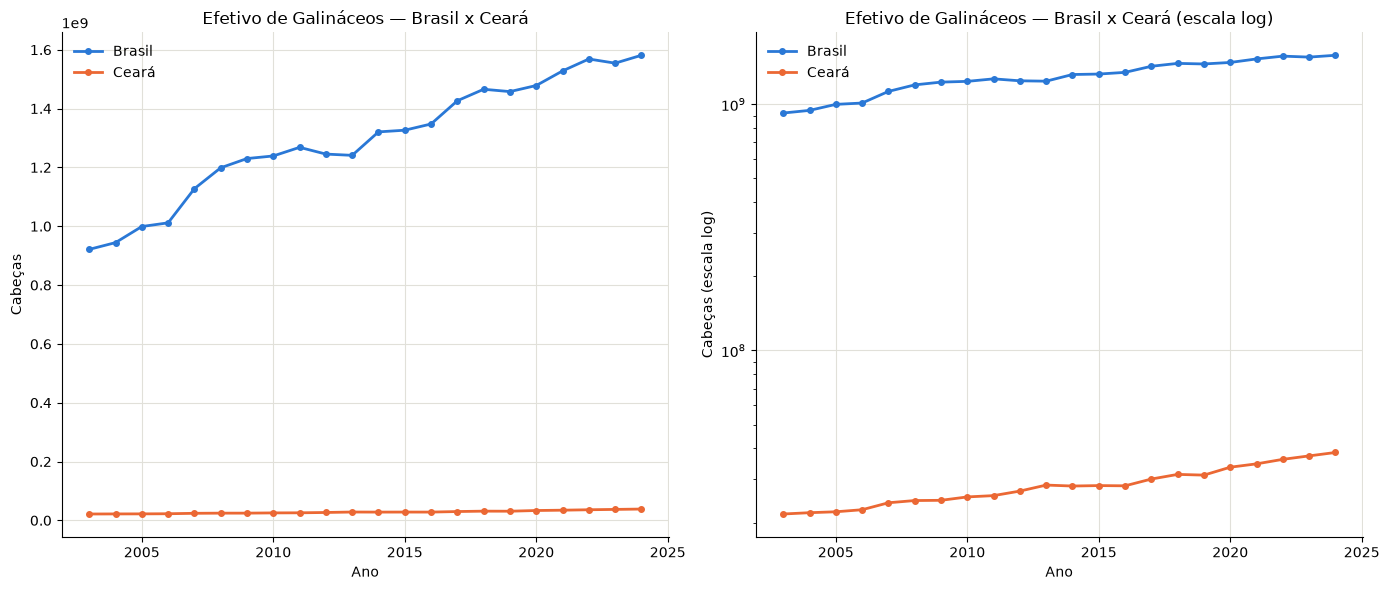

In [29]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}
series_galinaceos = {"Brasil": projecao_galinaceos_brasil['Galináceos - total'], "Ceará": projecao_galinaceos_ceara['Galináceos - total']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for territorio, cor in cores.items():
    serie = series_galinaceos[territorio]
    ax1.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax2.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax1.set_title("Efetivo de Galináceos — Brasil x Ceará")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Cabeças")
ax1.grid(True, color="#e1e0d9", linewidth=0.8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

ax2.set_yscale("log")
ax2.set_title("Efetivo de Galináceos — Brasil x Ceará (escala log)")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Cabeças (escala log)")
ax2.grid(True, color="#e1e0d9", linewidth=0.8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [30]:
print(projecao_galinaceos_brasil)
print()
print(projecao_galinaceos_ceara)

tipo_rebanho_nome  Galináceos - total
ano_nome                             
2003                     9.213228e+08
2004                     9.442983e+08
2005                     9.990412e+08
2006                     1.011516e+09
2007                     1.127659e+09
2008                     1.198704e+09
2009                     1.230087e+09
2010                     1.238913e+09
2011                     1.268209e+09
2012                     1.245269e+09
2013                     1.240995e+09
2014                     1.320749e+09
2015                     1.326453e+09
2016                     1.347626e+09
2017                     1.426659e+09
2018                     1.465647e+09
2019                     1.457697e+09
2020                     1.478424e+09
2021                     1.528032e+09
2022                     1.568518e+09
2023                     1.554374e+09
2024                     1.581216e+09

tipo_rebanho_nome  Galináceos - total
ano_nome                             
2003       

## Participação do Ceará no Brasil (%)

In [31]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}

### Bovino

Quanto o Ceará representa do efetivo de bovino do Brasil, ano a ano?

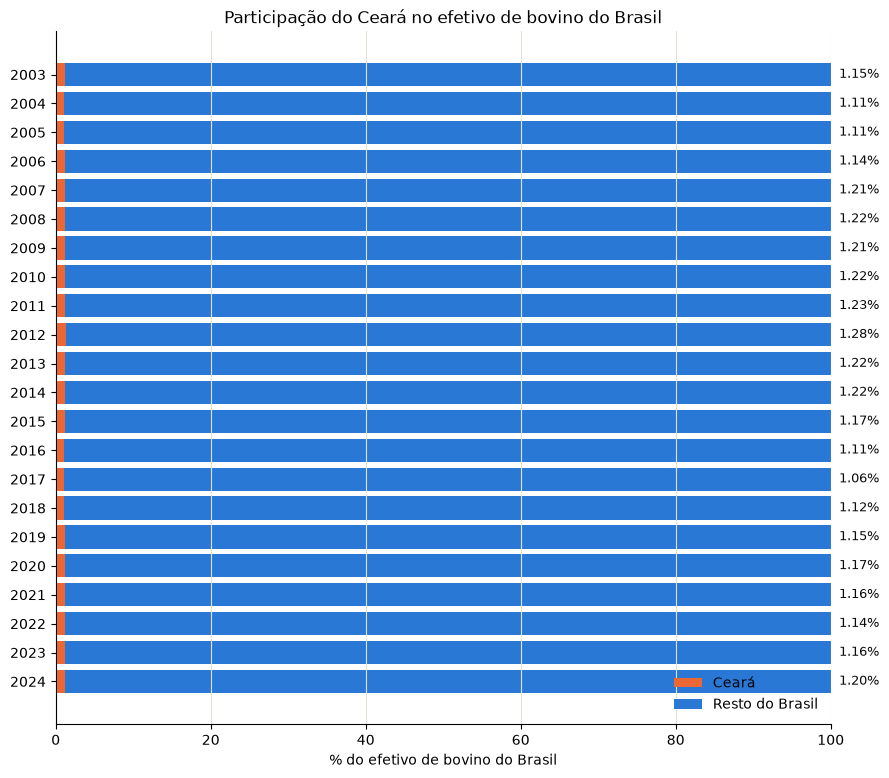

ano_nome
2003    1.152771
2004    1.109744
2005    1.109900
2006    1.142664
2007    1.213650
2008    1.216234
2009    1.214995
2010    1.215100
2011    1.228579
2012    1.284894
2013    1.223562
2014    1.222953
2015    1.169125
2016    1.112058
2017    1.063889
2018    1.124071
2019    1.154823
2020    1.171943
2021    1.160722
2022    1.141866
2023    1.161748
2024    1.201167
Name: Bovino, dtype: float64


In [32]:
percentual_bovino = (projecao_bovino_ceara['Bovino'] / projecao_bovino_brasil['Bovino']) * 100
resto_bovino = 100 - percentual_bovino

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_bovino.index, percentual_bovino, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_bovino.index, resto_bovino, left=percentual_bovino, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_bovino.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_bovino.index)
ax.invert_yaxis()
ax.set_xlabel("% do efetivo de bovino do Brasil")
ax.set_title("Participação do Ceará no efetivo de bovino do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_bovino)

### Caprino

Quanto o Ceará representa do efetivo de caprino do Brasil, ano a ano?

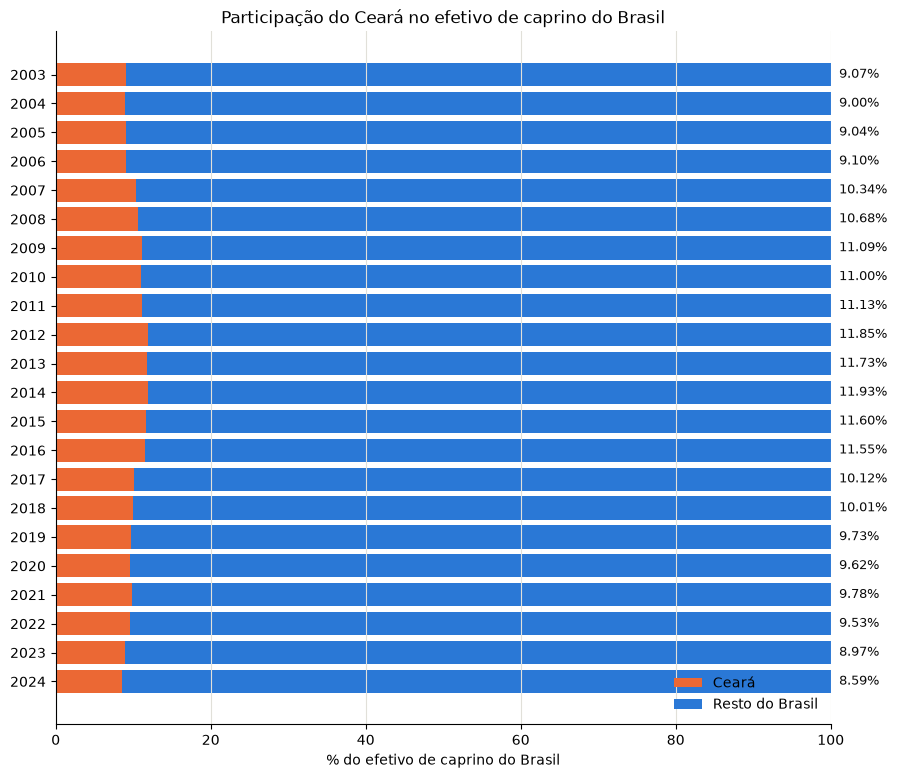

ano_nome
2003     9.069886
2004     9.000379
2005     9.039091
2006     9.101761
2007    10.337013
2008    10.676489
2009    11.086597
2010    11.002016
2011    11.133207
2012    11.845942
2013    11.729559
2014    11.928959
2015    11.598610
2016    11.552818
2017    10.115412
2018    10.012606
2019     9.726132
2020     9.624089
2021     9.782500
2022     9.525757
2023     8.972237
2024     8.588937
Name: Caprino, dtype: float64


In [33]:
percentual_caprino = (projecao_caprino_ceara['Caprino'] / projecao_caprino_brasil['Caprino']) * 100
resto_caprino = 100 - percentual_caprino

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_caprino.index, percentual_caprino, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_caprino.index, resto_caprino, left=percentual_caprino, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_caprino.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_caprino.index)
ax.invert_yaxis()
ax.set_xlabel("% do efetivo de caprino do Brasil")
ax.set_title("Participação do Ceará no efetivo de caprino do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_caprino)

### Ovino

Quanto o Ceará representa do efetivo de ovino do Brasil, ano a ano?

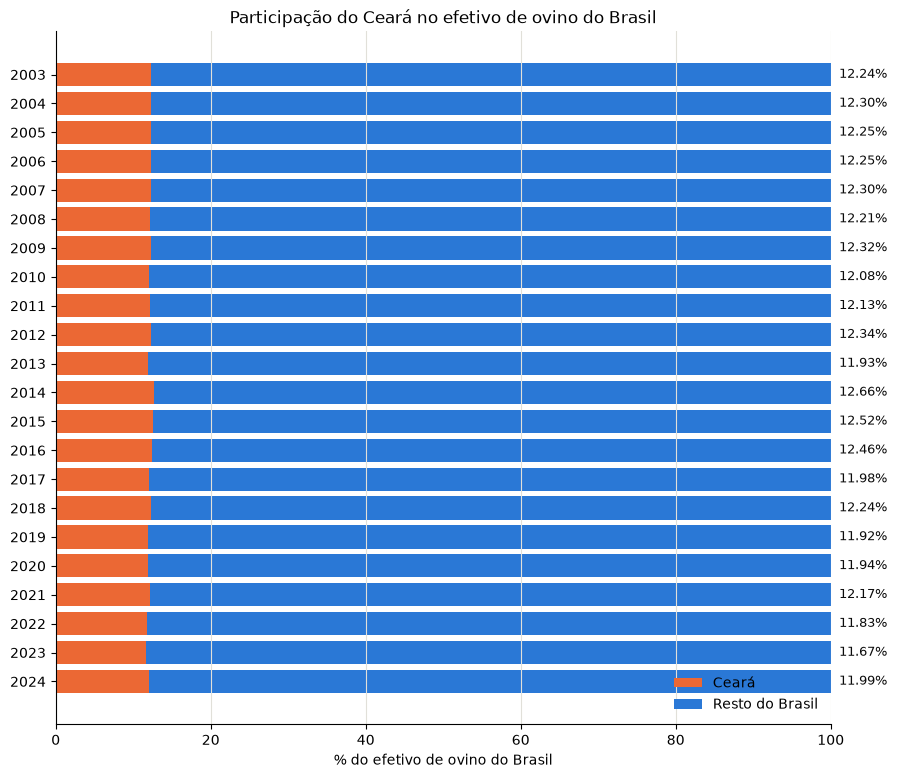

ano_nome
2003    12.241631
2004    12.302218
2005    12.247735
2006    12.246103
2007    12.304385
2008    12.212460
2009    12.319369
2010    12.076081
2011    12.126779
2012    12.335668
2013    11.929393
2014    12.656237
2015    12.519973
2016    12.464908
2017    11.977970
2018    12.236897
2019    11.919210
2020    11.939176
2021    12.172540
2022    11.828745
2023    11.666141
2024    11.985930
Name: Ovino, dtype: float64


In [34]:
percentual_ovino = (projecao_ovino_ceara['Ovino'] / projecao_ovino_brasil['Ovino']) * 100
resto_ovino = 100 - percentual_ovino

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_ovino.index, percentual_ovino, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_ovino.index, resto_ovino, left=percentual_ovino, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_ovino.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_ovino.index)
ax.invert_yaxis()
ax.set_xlabel("% do efetivo de ovino do Brasil")
ax.set_title("Participação do Ceará no efetivo de ovino do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_ovino)

### Suíno

Quanto o Ceará representa do efetivo de suíno do Brasil, ano a ano?

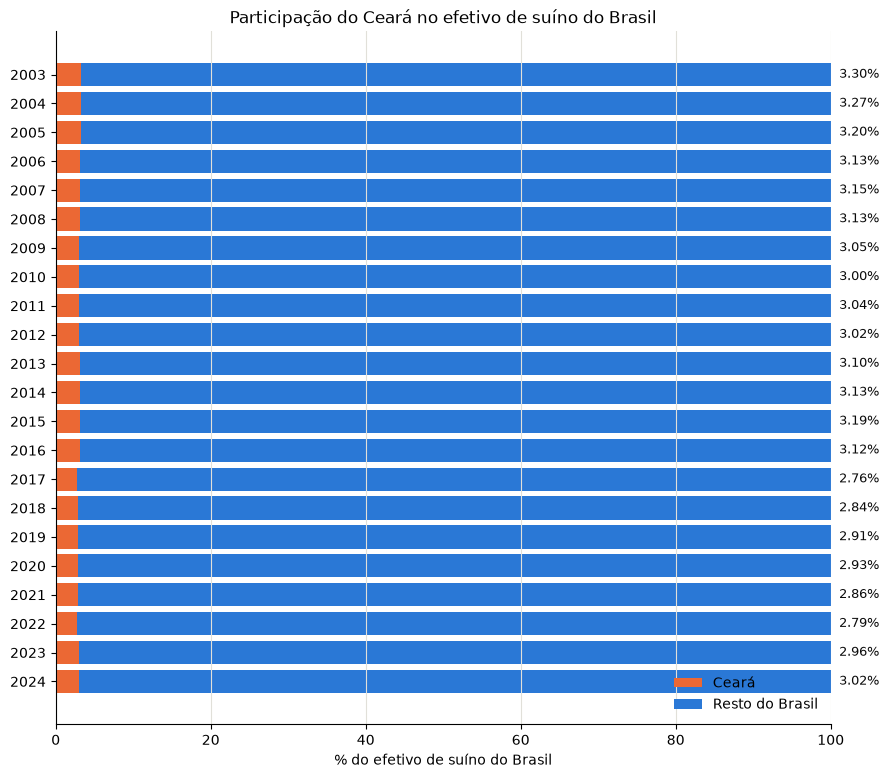

ano_nome
2003    3.303876
2004    3.273336
2005    3.198486
2006    3.131192
2007    3.151127
2008    3.130442
2009    3.050062
2010    2.997506
2011    3.036660
2012    3.023714
2013    3.098293
2014    3.132340
2015    3.187172
2016    3.120199
2017    2.762519
2018    2.840086
2019    2.908610
2020    2.933267
2021    2.856403
2022    2.785393
2023    2.964804
2024    3.016023
Name: Suíno - total, dtype: float64


In [35]:
percentual_suino = (projecao_suino_ceara['Suíno - total'] / projecao_suino_brasil['Suíno - total']) * 100
resto_suino = 100 - percentual_suino

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_suino.index, percentual_suino, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_suino.index, resto_suino, left=percentual_suino, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_suino.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_suino.index)
ax.invert_yaxis()
ax.set_xlabel("% do efetivo de suíno do Brasil")
ax.set_title("Participação do Ceará no efetivo de suíno do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_suino)

### Galináceos

Quanto o Ceará representa do efetivo de galináceos do Brasil, ano a ano?

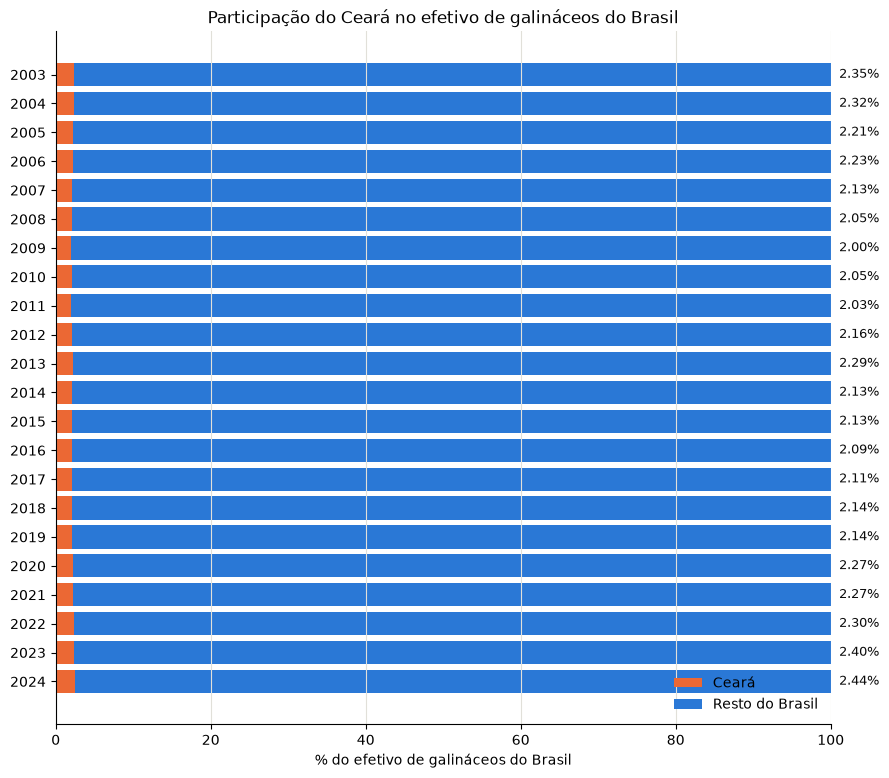

ano_nome
2003    2.351235
2004    2.322261
2005    2.213993
2006    2.228854
2007    2.133915
2008    2.049726
2009    2.001609
2010    2.051413
2011    2.028708
2012    2.155644
2013    2.288022
2014    2.130734
2015    2.130403
2016    2.092485
2017    2.105909
2018    2.140704
2019    2.138131
2020    2.270150
2021    2.266204
2022    2.302881
2023    2.399927
2024    2.435973
Name: Galináceos - total, dtype: float64


In [36]:
percentual_galinaceos = (projecao_galinaceos_ceara['Galináceos - total'] / projecao_galinaceos_brasil['Galináceos - total']) * 100
resto_galinaceos = 100 - percentual_galinaceos

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_galinaceos.index, percentual_galinaceos, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_galinaceos.index, resto_galinaceos, left=percentual_galinaceos, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_galinaceos.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_galinaceos.index)
ax.invert_yaxis()
ax.set_xlabel("% do efetivo de galináceos do Brasil")
ax.set_title("Participação do Ceará no efetivo de galináceos do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_galinaceos)

## Análise por Município

### Bovino

Quais municípios têm maior e menor efetivo de bovino, e como o Ceará se reparte entre eles (2003 x 2023)?

In [37]:
pivot_municipios_bovino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Bovino') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_bovino

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,5311.0,2112.0,12048.0,40609.0,8735.0,3058.0,1715.0,15233.0,10858.0,3541.0,7357.0,12513.0,6412.0,10408.0,5504.0,10005.0,2985.0,10493.0,13815.0,18516.0,7045.0,22500.0,8156.0,4425.0,13894.0,2244.0,6632.0,9803.0,15240.0,34949.0,24734.0,6923.0,7502.0,30539.0,4380.0,6786.0,10008.0,17764.0,11806.0,3125.0,8133.0,10209.0,7350.0,18397.0,18460.0,2200.0,5563.0,11800.0,8838.0,39368.0,13441.0,2932.0,4351.0,8900.0,7662.0,3315.0,9622.0,9219.0,3053.0,1417.0,2165.0,3471.0,18468.0,2322.0,3015.0,4079.0,2785.0,5940.0,901.0,8515.0,3340.0,11300.0,4818.0,8300.0,5753.0,41544.0,36101.0,35761.0,7629.0,8491.0,11101.0,11635.0,16092.0,19638.0,4212.0,2852.0,8553.0,19558.0,7556.0,7980.0,8103.0,44791.0,12877.0,42811.0,13157.0,12943.0,4951.0,1386.0,7700.0,14860.0,25297.0,16071.0,18392.0,1432.0,18215.0,9296.0,2468.0,9268.0,26246.0,1435.0,13707.0,15400.0,13406.0,15404.0,39926.0,13136.0,46891.0,5238.0,5528.0,3598.0,907.0,4679.0,10961.0,16967.0,8412.0,16294.0,6970.0,2806.0,3502.0,1921.0,2691.0,2803.0,4555.0,5807.0,27552.0,5658.0,24800.0,3038.0,16545

In [38]:
total_municipios_bovino = pivot_municipios_bovino.sum(axis=0).sort_values(ascending=False)
top8_melhores_bovino = total_municipios_bovino.head(8)
top8_piores_bovino = total_municipios_bovino.tail(8).sort_values()

print("Top 8 melhores municípios - Bovino (soma 2003-2024):")
print(top8_melhores_bovino)
print()
print("Top 8 piores municípios - Bovino (soma 2003-2024):")
print(top8_piores_bovino)

Top 8 melhores municípios - Bovino (soma 2003-2024):
territorio_nome
Quixeramobim - CE    1833715.0
Morada Nova - CE     1513068.0
Iguatu - CE          1171685.0
Tauá - CE            1116001.0
Jaguaribe - CE       1109278.0
Acopiara - CE        1089033.0
Quixadá - CE         1052312.0
Jaguaretama - CE     1049592.0
dtype: float64

Top 8 piores municípios - Bovino (soma 2003-2024):
territorio_nome
Guaramiranga - CE              12518.0
Mulungu - CE                   23037.0
Jijoca de Jericoacoara - CE    25447.0
Meruoca - CE                   26521.0
Fortim - CE                    32370.0
Maracanaú - CE                 38172.0
Eusébio - CE                   40828.0
Pacujá - CE                    40930.0
dtype: float64


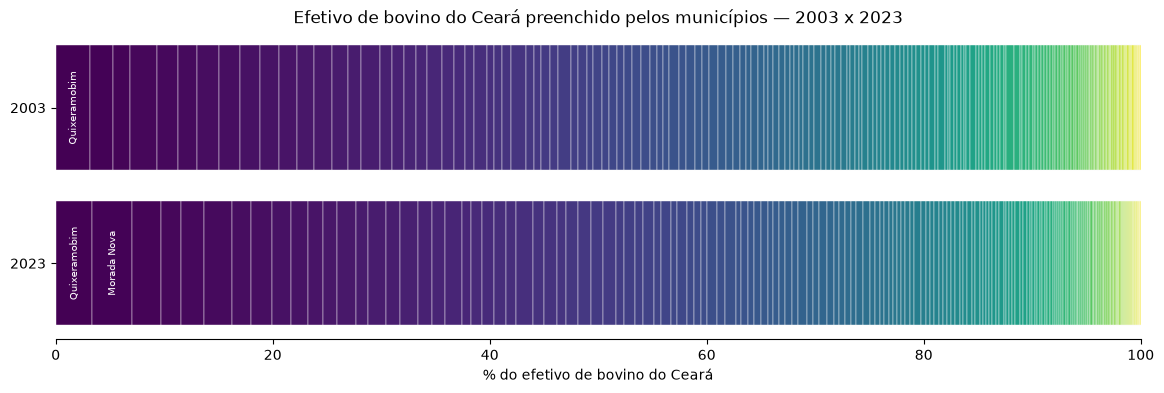

In [39]:
participacao_municipios_bovino = pivot_municipios_bovino.div(pivot_municipios_bovino.sum(axis=1), axis=0) * 100
ordem_municipios_bovino = total_municipios_bovino.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_bovino)
cor_por_municipio_bovino = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_bovino)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_bovino:
        pct = participacao_municipios_bovino.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_bovino[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do efetivo de bovino do Ceará")
ax.set_title("Efetivo de bovino do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Caprino

Quais municípios têm maior e menor efetivo de caprino, e como o Ceará se reparte entre eles (2003 x 2023)?

In [40]:
pivot_municipios_caprino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Caprino') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_caprino

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,280.0,45.0,1948.0,8118.0,12315.0,613.0,267.0,5705.0,4650.0,1025.0,3564.0,1260.0,3734.0,827.0,1591.0,709.0,712.0,23589.0,1461.0,2472.0,743.0,6700.0,1004.0,164.0,2351.0,2818.0,645.0,4954.0,5797.0,14388.0,1014.0,4887.0,5325.0,13087.0,318.0,2985.0,3879.0,5617.0,810.0,2910.0,988.0,9180.0,5742.0,4936.0,2280.0,3120.0,664.0,3950.0,6098.0,9643.0,1011.0,2343.0,1232.0,3090.0,1665.0,263.0,1372.0,2355.0,64.0,878.0,1900.0,1828.0,24647.0,525.0,3493.0,749.0,198.0,1138.0,56.0,5450.0,845.0,3900.0,1630.0,2370.0,388.0,5946.0,1810.0,43505.0,831.0,792.0,2860.0,7592.0,1822.0,8494.0,130.0,2591.0,1858.0,8311.0,2693.0,1046.0,5703.0,15396.0,2857.0,11209.0,16966.0,1644.0,773.0,1258.0,388.0,2380.0,1867.0,5400.0,4736.0,249.0,822.0,4078.0,2581.0,3285.0,3399.0,473.0,836.0,2700.0,4516.0,1590.0,14230.0,5096.0,14658.0,4110.0,3182.0,1125.0,79.0,401.0,4747.0,4099.0,1564.0,2560.0,390.0,197.0,386.0,1821.0,4194.0,87.0,180.0,389.0,24129.0,4013.0,15260.0,333.0,13040.0,1835.0,85.0,1050.0,637.0,16078.0,664.0,1059.0,2187.0,4126.0,7200.0,2098.0,7450.0,8626.

In [41]:
total_municipios_caprino = pivot_municipios_caprino.sum(axis=0).sort_values(ascending=False)
top8_melhores_caprino = total_municipios_caprino.head(8)
top8_piores_caprino = total_municipios_caprino.tail(8).sort_values()

print("Top 8 melhores municípios - Caprino (soma 2003-2024):")
print(top8_melhores_caprino)
print()
print("Top 8 piores municípios - Caprino (soma 2003-2024):")
print(top8_piores_caprino)

Top 8 melhores municípios - Caprino (soma 2003-2024):
territorio_nome
Tauá - CE              1584792.0
Independência - CE     1063390.0
Santa Quitéria - CE     835102.0
Aiuaba - CE             621298.0
Granja - CE             615217.0
Arneiroz - CE           584710.0
Parambu - CE            556810.0
Tamboril - CE           548781.0
dtype: float64

Top 8 piores municípios - Caprino (soma 2003-2024):
territorio_nome
Fortaleza - CE       1881.0
Guaramiranga - CE    2223.0
Acarape - CE         3814.0
Palmácia - CE        4723.0
Mulungu - CE         5059.0
Redenção - CE        6134.0
Paracuru - CE        6435.0
Barreira - CE        6606.0
dtype: float64


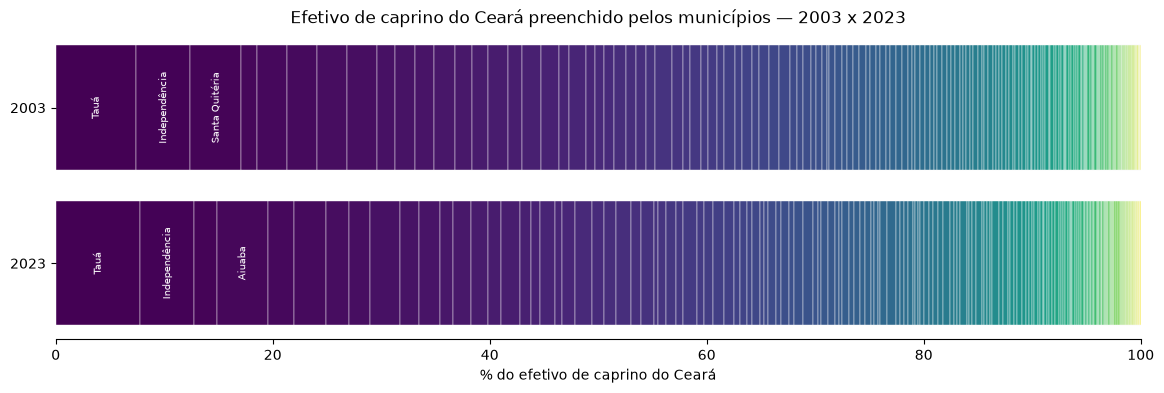

In [42]:
participacao_municipios_caprino = pivot_municipios_caprino.div(pivot_municipios_caprino.sum(axis=1), axis=0) * 100
ordem_municipios_caprino = total_municipios_caprino.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_caprino)
cor_por_municipio_caprino = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_caprino)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_caprino:
        pct = participacao_municipios_caprino.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_caprino[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do efetivo de caprino do Ceará")
ax.set_title("Efetivo de caprino do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Ovino

Quais municípios têm maior e menor efetivo de ovino, e como o Ceará se reparte entre eles (2003 x 2023)?

In [43]:
pivot_municipios_ovino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Ovino') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_ovino

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,278.0,360.0,7084.0,19087.0,18372.0,41.0,78.0,11463.0,9376.0,2911.0,6139.0,4410.0,10211.0,2586.0,6085.0,1527.0,496.0,27282.0,4691.0,3787.0,2867.0,24640.0,1144.0,780.0,2697.0,3755.0,907.0,10077.0,14704.0,45337.0,2502.0,9155.0,13995.0,20546.0,870.0,9091.0,1250.0,13287.0,2214.0,915.0,7224.0,20386.0,9521.0,7918.0,3690.0,1521.0,1326.0,9730.0,8140.0,60708.0,1325.0,875.0,5962.0,9980.0,4237.0,850.0,863.0,5639.0,1265.0,1476.0,600.0,3217.0,13241.0,544.0,1325.0,1894.0,697.0,668.0,191.0,19339.0,910.0,10700.0,300.0,8500.0,1264.0,13776.0,7105.0,91766.0,10971.0,1972.0,2702.0,5076.0,7095.0,18222.0,580.0,2487.0,2503.0,10039.0,6486.0,6268.0,8388.0,53365.0,10706.0,36760.0,20546.0,1962.0,802.0,1826.0,1863.0,4590.0,6837.0,13970.0,12130.0,143.0,3585.0,5048.0,1803.0,3466.0,5428.0,53.0,1815.0,13630.0,10957.0,1534.0,30028.0,8635.0,44003.0,11546.0,4167.0,756.0,25.0,382.0,15420.0,21958.0,4963.0,5288.0,1110.0,1053.0,103.0,1841.0,4142.0,1980.0,1610.0,1376.0,49645.0,7523.0,24150.0,817.0,16470.0,1760.0,588.0,4388.0,2093.0,6049.0,1098.0,3953.0,

In [44]:
total_municipios_ovino = pivot_municipios_ovino.sum(axis=0).sort_values(ascending=False)
top8_melhores_ovino = total_municipios_ovino.head(8)
top8_piores_ovino = total_municipios_ovino.tail(8).sort_values()

print("Top 8 melhores municípios - Ovino (soma 2003-2024):")
print(top8_melhores_ovino)
print()
print("Top 8 piores municípios - Ovino (soma 2003-2024):")
print(top8_piores_ovino)

Top 8 melhores municípios - Ovino (soma 2003-2024):
territorio_nome
Tauá - CE              3162844.0
Independência - CE     2249382.0
Crateús - CE           1497827.0
Jaguaretama - CE       1383074.0
Morada Nova - CE       1225289.0
Santa Quitéria - CE    1225288.0
Parambu - CE           1156362.0
Jaguaribe - CE         1111157.0
dtype: float64

Top 8 piores municípios - Ovino (soma 2003-2024):
territorio_nome
Mulungu - CE          2475.0
Meruoca - CE          3127.0
Alcântaras - CE       3146.0
Pacoti - CE           3714.0
Guaramiranga - CE     4075.0
Redenção - CE         7496.0
Uruburetama - CE      8407.0
Acarape - CE         10007.0
dtype: float64


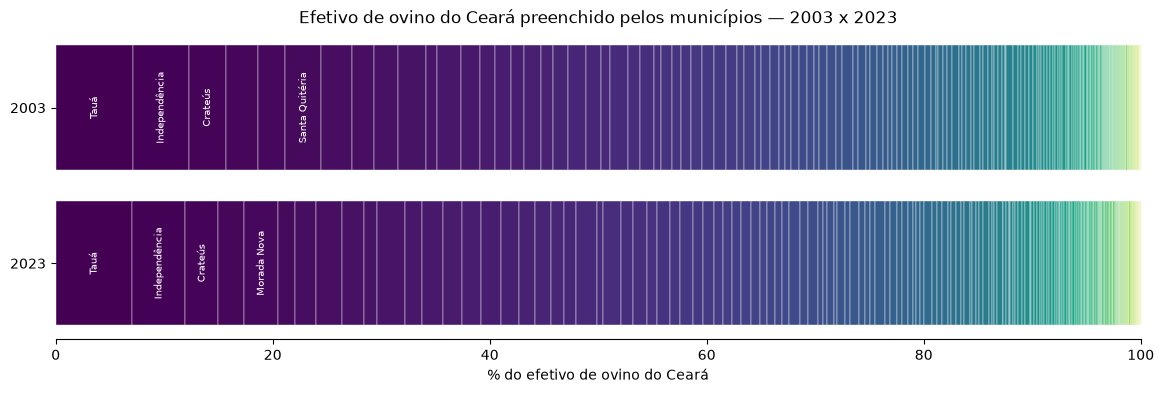

In [45]:
participacao_municipios_ovino = pivot_municipios_ovino.div(pivot_municipios_ovino.sum(axis=1), axis=0) * 100
ordem_municipios_ovino = total_municipios_ovino.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_ovino)
cor_por_municipio_ovino = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_ovino)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_ovino:
        pct = participacao_municipios_ovino.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_ovino[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do efetivo de ovino do Ceará")
ax.set_title("Efetivo de ovino do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Suíno

Quais municípios têm maior e menor efetivo de suíno, e como o Ceará se reparte entre eles (2003 x 2023)?

In [46]:
pivot_municipios_suino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Suíno - total') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_suino

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,539.0,1896.0,8237.0,22158.0,7073.0,2801.0,886.0,3134.0,6504.0,830.0,3575.0,6194.0,2470.0,3039.0,5884.0,3726.0,2294.0,3697.0,7018.0,9340.0,1585.0,4870.0,2832.0,1009.0,5388.0,7971.0,4144.0,5641.0,6918.0,19284.0,2289.0,11166.0,6526.0,19896.0,1495.0,4091.0,6055.0,13664.0,6279.0,3566.0,5484.0,9230.0,3840.0,9060.0,4990.0,4650.0,788.0,4320.0,6661.0,14938.0,4378.0,2799.0,5524.0,4925.0,1572.0,1099.0,5910.0,4228.0,950.0,845.0,6960.0,2756.0,45003.0,1108.0,15995.0,2673.0,4797.0,4909.0,334.0,4051.0,1198.0,2470.0,4327.0,1680.0,255.0,12794.0,10260.0,14720.0,4744.0,2439.0,4013.0,8226.0,1741.0,6052.0,1461.0,992.0,3666.0,18634.0,4255.0,4984.0,5520.0,7006.0,1561.0,7482.0,3426.0,4787.0,1352.0,3402.0,474.0,5868.0,8000.0,4006.0,6530.0,5612.0,6266.0,7725.0,2418.0,16323.0,9801.0,1356.0,3696.0,3130.0,10841.0,5467.0,21308.0,5255.0,10721.0,3612.0,3819.0,3060.0,245.0,1436.0,5195.0,12262.0,3261.0,3669.0,738.0,4290.0,1368.0,2703.0,1008.0,1159.0,1818.0,1922.0,16058.0,3935.0,12970.0,700.0,8783.0,3085.0,985.0,8765.0,3020.0,5123.0,2372.0,2870.0,

In [47]:
total_municipios_suino = pivot_municipios_suino.sum(axis=0).sort_values(ascending=False)
top8_melhores_suino = total_municipios_suino.head(8)
top8_piores_suino = total_municipios_suino.tail(8).sort_values()

print("Top 8 melhores municípios - Suíno (soma 2003-2024):")
print(top8_melhores_suino)
print()
print("Top 8 piores municípios - Suíno (soma 2003-2024):")
print(top8_piores_suino)

Top 8 melhores municípios - Suíno (soma 2003-2024):
territorio_nome
Granja - CE             1085087.0
Viçosa do Ceará - CE     850748.0
Massapê - CE             551400.0
Canindé - CE             517659.0
Morada Nova - CE         490092.0
Tauá - CE                462484.0
Acopiara - CE            377688.0
Itapipoca - CE           358446.0
dtype: float64

Top 8 piores municípios - Suíno (soma 2003-2024):
territorio_nome
Guaramiranga - CE          6390.0
Antonina do Norte - CE    15423.0
Eusébio - CE              15567.0
Fortaleza - CE            16957.0
Chorozinho - CE           19633.0
Penaforte - CE            20208.0
Icapuí - CE               20635.0
Pindoretama - CE          23609.0
dtype: float64


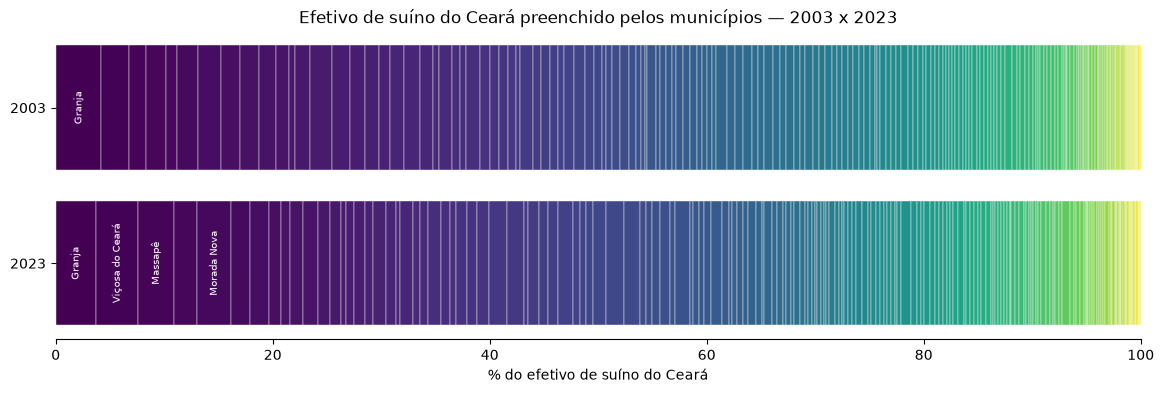

In [48]:
participacao_municipios_suino = pivot_municipios_suino.div(pivot_municipios_suino.sum(axis=1), axis=0) * 100
ordem_municipios_suino = total_municipios_suino.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_suino)
cor_por_municipio_suino = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_suino)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_suino:
        pct = participacao_municipios_suino.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_suino[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do efetivo de suíno do Ceará")
ax.set_title("Efetivo de suíno do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Galináceos

Quais municípios têm maior e menor efetivo de galináceos, e como o Ceará se reparte entre eles (2003 x 2023)?

In [49]:
pivot_municipios_galinaceos = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Galináceos - total') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_galinaceos

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,25403.0,2105.0,86321.0,344986.0,33788.0,36779.0,14247.0,10697.0,61699.0,5410.0,23687.0,1506308.0,26878.0,35410.0,30640.0,43329.0,38091.0,17960.0,106587.0,87256.0,17518.0,49050.0,121008.0,519125.0,53712.0,15215.0,49540.0,833003.0,53421.0,132381.0,106129.0,40421.0,43216.0,148369.0,58734.0,14093.0,80134.0,41251.0,85190.0,13442.0,931736.0,35025.0,21125.0,685712.0,64682.0,6107.0,130735.0,64000.0,32748.0,113054.0,192198.0,29380.0,33137.0,37800.0,23092.0,131670.0,59505.0,30747.0,419095.0,6958.0,19744.0,19997.0,90452.0,9342.0,40781.0,12447.0,342093.0,42329.0,3039.0,34490.0,1318603.0,108500.0,42508.0,17560.0,9503.0,156093.0,358630.0,92409.0,31991.0,25357.0,49980.0,80435.0,26535.0,49081.0,25725.0,15337.0,65667.0,330577.0,42138.0,34535.0,39745.0,90699.0,15741.0,72149.0,45708.0,86257.0,17246.0,23509.0,77824.0,50085.0,91639.0,35795.0,61569.0,42450.0,467560.0,25110.0,7190.0,163821.0,141573.0,25829.0,182006.0,44670.0,30123.0,78353.0,121972.0,30617.0,69506.0,11960.0,28158.0,11912.0,8241.0,26344.0,33447.0,79703.0,39934.0,36194.0

In [50]:
total_municipios_galinaceos = pivot_municipios_galinaceos.sum(axis=0).sort_values(ascending=False)
top8_melhores_galinaceos = total_municipios_galinaceos.head(8)
top8_piores_galinaceos = total_municipios_galinaceos.tail(8).sort_values()

print("Top 8 melhores municípios - Galináceos (soma 2003-2024):")
print(top8_melhores_galinaceos)
print()
print("Top 8 piores municípios - Galináceos (soma 2003-2024):")
print(top8_piores_galinaceos)

Top 8 melhores municípios - Galináceos (soma 2003-2024):
territorio_nome
Quixadá - CE       68833338.0
Beberibe - CE      47703337.0
Horizonte - CE     45148727.0
Aquiraz - CE       40963560.0
Cascavel - CE      31024864.0
Paracuru - CE      18102127.0
Pacajus - CE       16172982.0
Maranguape - CE    16104609.0
dtype: float64

Top 8 piores municípios - Galináceos (soma 2003-2024):
territorio_nome
Guaramiranga - CE          92788.0
Antonina do Norte - CE    131030.0
Chaval - CE               160120.0
Martinópole - CE          173272.0
Acarape - CE              223659.0
Pacujá - CE               236599.0
Fortim - CE               240040.0
Penaforte - CE            261372.0
dtype: float64


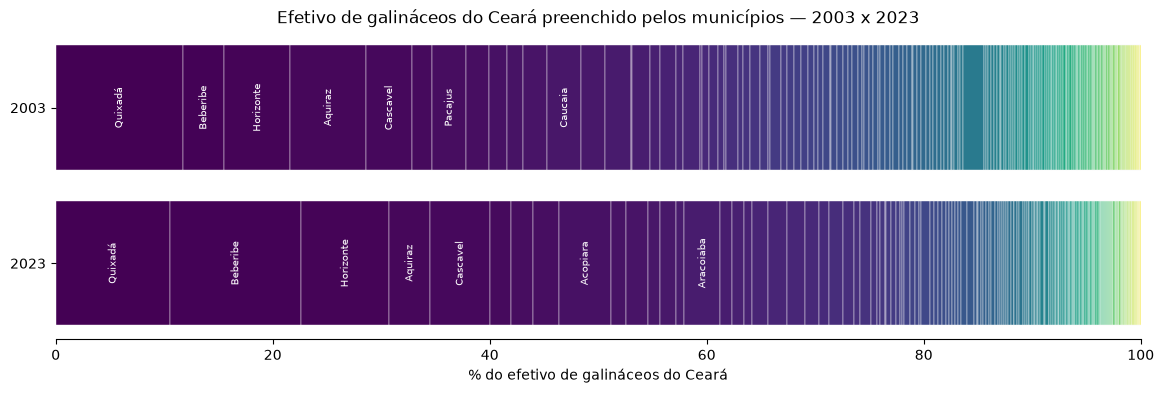

In [51]:
participacao_municipios_galinaceos = pivot_municipios_galinaceos.div(pivot_municipios_galinaceos.sum(axis=1), axis=0) * 100
ordem_municipios_galinaceos = total_municipios_galinaceos.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_galinaceos)
cor_por_municipio_galinaceos = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_galinaceos)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_galinaceos:
        pct = participacao_municipios_galinaceos.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_galinaceos[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do efetivo de galináceos do Ceará")
ax.set_title("Efetivo de galináceos do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

## Crescimento (2003 → 2023)

### Espécies (Ceará)

Quanto cresceu o efetivo de cada espécie no Ceará entre 2003 e 2023? (séries independentes, não somadas)

In [52]:
print("Crescimento do efetivo por espécie (Ceará, 2003 → 2023):")
fator_bovino = projecao_bovino_ceara.loc[2023, 'Bovino'] / projecao_bovino_ceara.loc[2003, 'Bovino']
print(f"Bovino: {fator_bovino:.2f}x")
fator_caprino = projecao_caprino_ceara.loc[2023, 'Caprino'] / projecao_caprino_ceara.loc[2003, 'Caprino']
print(f"Caprino: {fator_caprino:.2f}x")
fator_ovino = projecao_ovino_ceara.loc[2023, 'Ovino'] / projecao_ovino_ceara.loc[2003, 'Ovino']
print(f"Ovino: {fator_ovino:.2f}x")
fator_suino = projecao_suino_ceara.loc[2023, 'Suíno - total'] / projecao_suino_ceara.loc[2003, 'Suíno - total']
print(f"Suíno: {fator_suino:.2f}x")
fator_galinaceos = projecao_galinaceos_ceara.loc[2023, 'Galináceos - total'] / projecao_galinaceos_ceara.loc[2003, 'Galináceos - total']
print(f"Galináceos: {fator_galinaceos:.2f}x")

Crescimento do efetivo por espécie (Ceará, 2003 → 2023):
Bovino: 1.23x
Caprino: 1.33x
Ovino: 1.43x
Suíno: 1.20x
Galináceos: 1.72x


### Municípios

Quais municípios mais cresceram em cada espécie, entre 2003 e 2023?

In [53]:
crescimento_municipios_bovino = (pivot_municipios_bovino.loc[2023] / pivot_municipios_bovino.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Bovino (2003 → 2023):")
for municipio, fator in crescimento_municipios_bovino.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Bovino (2003 → 2023):
Jucás - CE: 2.94x
Potengi - CE: 2.63x
Nova Olinda - CE: 2.56x
Campos Sales - CE: 2.40x
Cariús - CE: 2.34x
Penaforte - CE: 2.33x
Milhã - CE: 2.24x
Hidrolândia - CE: 2.22x
Morada Nova - CE: 2.15x
Várzea Alegre - CE: 2.08x


In [54]:
crescimento_municipios_caprino = (pivot_municipios_caprino.loc[2023] / pivot_municipios_caprino.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Caprino (2003 → 2023):")
for municipio, fator in crescimento_municipios_caprino.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Caprino (2003 → 2023):
Guaiúba - CE: 10.20x
Redenção - CE: 9.16x
Pindoretama - CE: 9.11x
Itaitinga - CE: 8.15x
Maranguape - CE: 6.97x
Crato - CE: 6.63x
Iracema - CE: 6.11x
Mulungu - CE: 5.16x
Icapuí - CE: 4.94x
Aiuaba - CE: 4.37x


In [55]:
crescimento_municipios_ovino = (pivot_municipios_ovino.loc[2023] / pivot_municipios_ovino.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Ovino (2003 → 2023):")
for municipio, fator in crescimento_municipios_ovino.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Ovino (2003 → 2023):
Abaiara - CE: 14.39x
Crato - CE: 11.02x
Nova Olinda - CE: 7.59x
Maracanaú - CE: 6.08x
Guaiúba - CE: 5.98x
Croatá - CE: 5.77x
Altaneira - CE: 5.77x
Mulungu - CE: 5.76x
Farias Brito - CE: 5.60x
Maranguape - CE: 5.00x


In [56]:
crescimento_municipios_suino = (pivot_municipios_suino.loc[2023] / pivot_municipios_suino.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Suíno (2003 → 2023):")
for municipio, fator in crescimento_municipios_suino.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Suíno (2003 → 2023):
Redenção - CE: 16.00x
Iracema - CE: 9.66x
Icapuí - CE: 6.58x
Pacajus - CE: 6.01x
Caridade - CE: 5.06x
Limoeiro do Norte - CE: 4.79x
Mulungu - CE: 4.69x
Juazeiro do Norte - CE: 4.58x
Tabuleiro do Norte - CE: 4.39x
Horizonte - CE: 4.22x


In [57]:
crescimento_municipios_galinaceos = (pivot_municipios_galinaceos.loc[2023] / pivot_municipios_galinaceos.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Galináceos (2003 → 2023):")
for municipio, fator in crescimento_municipios_galinaceos.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Galináceos (2003 → 2023):
Aracoiaba - CE: 34.87x
Maracanaú - CE: 14.80x
Paraipaba - CE: 12.95x
Abaiara - CE: 11.93x
Acarape - CE: 11.40x
Caridade - CE: 9.39x
Beberibe - CE: 5.42x
Acopiara - CE: 5.15x
Porteiras - CE: 4.91x
Eusébio - CE: 4.19x


## Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia

In [58]:
cidades_investigar = ["Fortaleza - CE", "Maracanaú - CE", "São Gonçalo do Amarante - CE", "Caucaia - CE"]
cores_investigar = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
cor_por_cidade_investigar = dict(zip(cidades_investigar, cores_investigar))

Como se compara a evolução do efetivo dessas 4 cidades, espécie por espécie?

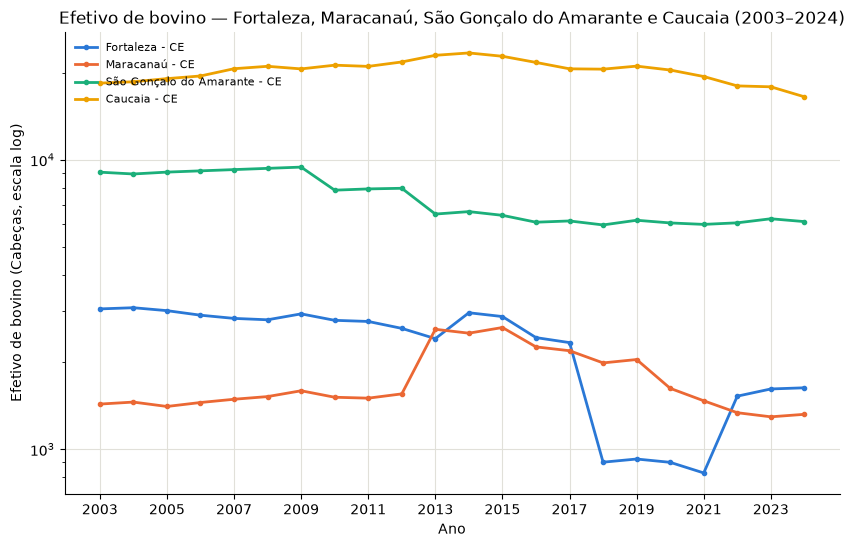

In [59]:
serie_cidades_bovino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Bovino') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_bovino[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Efetivo de bovino (Cabeças, escala log)")
ax.set_title("Efetivo de bovino — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

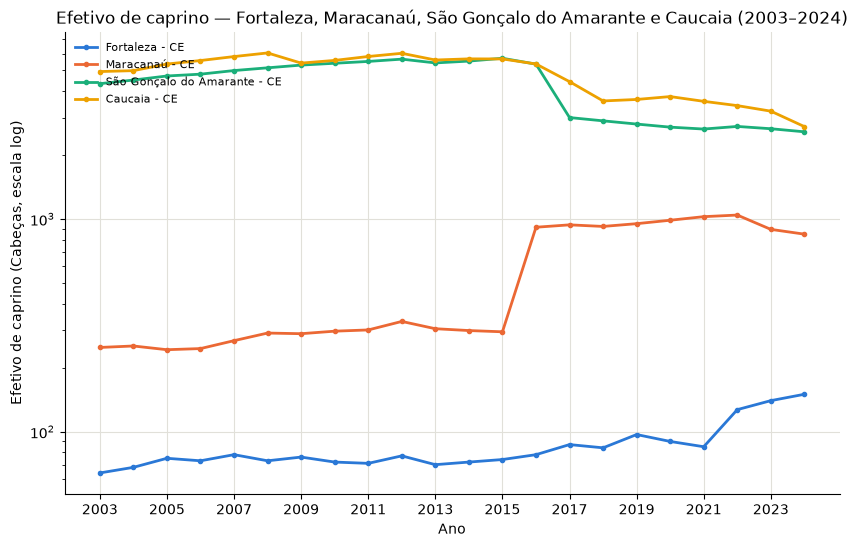

In [60]:
serie_cidades_caprino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Caprino') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_caprino[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Efetivo de caprino (Cabeças, escala log)")
ax.set_title("Efetivo de caprino — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

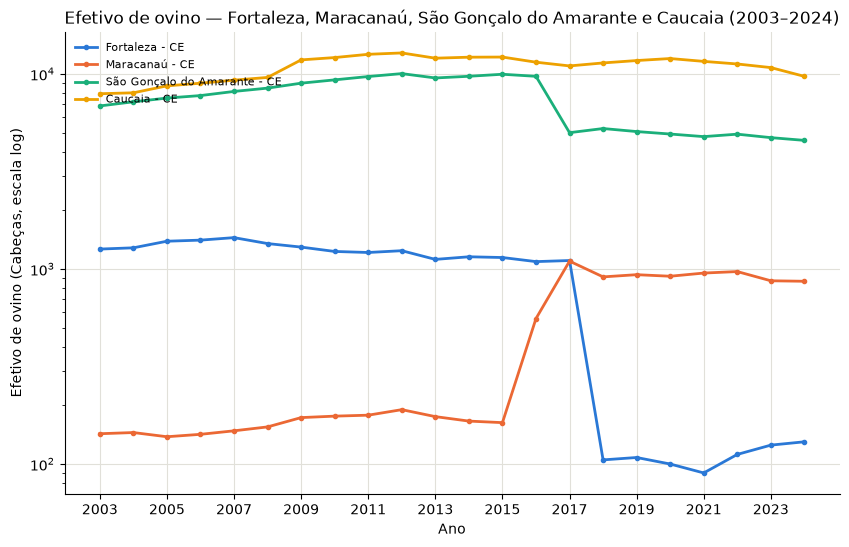

In [61]:
serie_cidades_ovino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Ovino') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_ovino[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Efetivo de ovino (Cabeças, escala log)")
ax.set_title("Efetivo de ovino — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

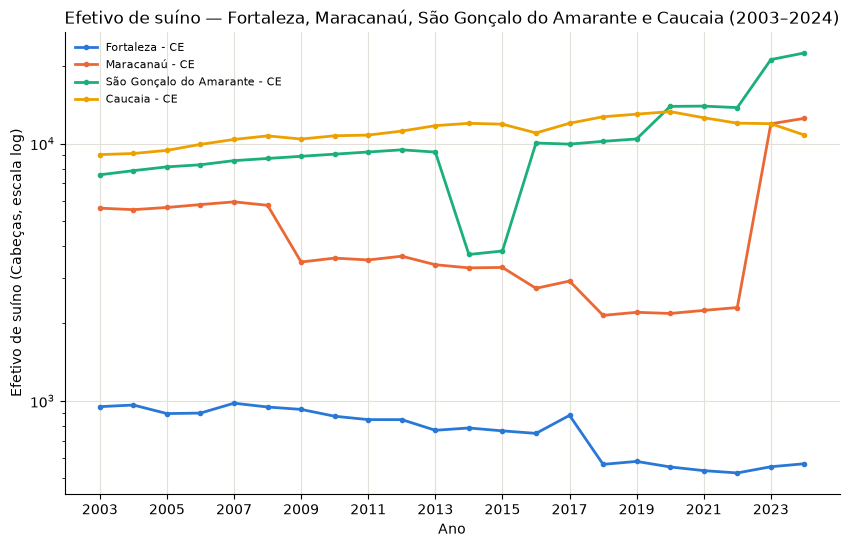

In [62]:
serie_cidades_suino = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Suíno - total') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_suino[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Efetivo de suíno (Cabeças, escala log)")
ax.set_title("Efetivo de suíno — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

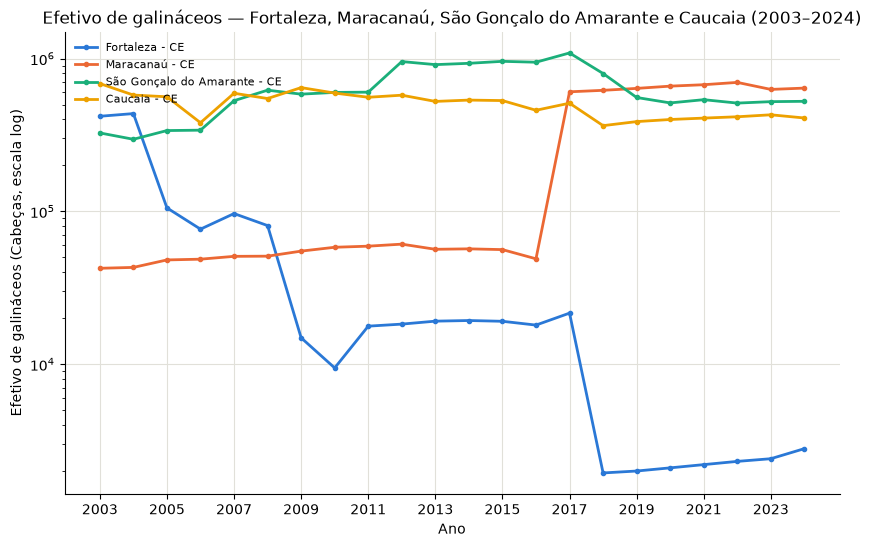

In [63]:
serie_cidades_galinaceos = df_nome[
    (df_nome['tipo_rebanho_nome'] == 'Galináceos - total') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_galinaceos[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Efetivo de galináceos (Cabeças, escala log)")
ax.set_title("Efetivo de galináceos — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

## Boxplot do Efetivo por Espécie (Ceará)

Como se distribui o efetivo de cada espécie entre os municípios e anos, e existem outliers?

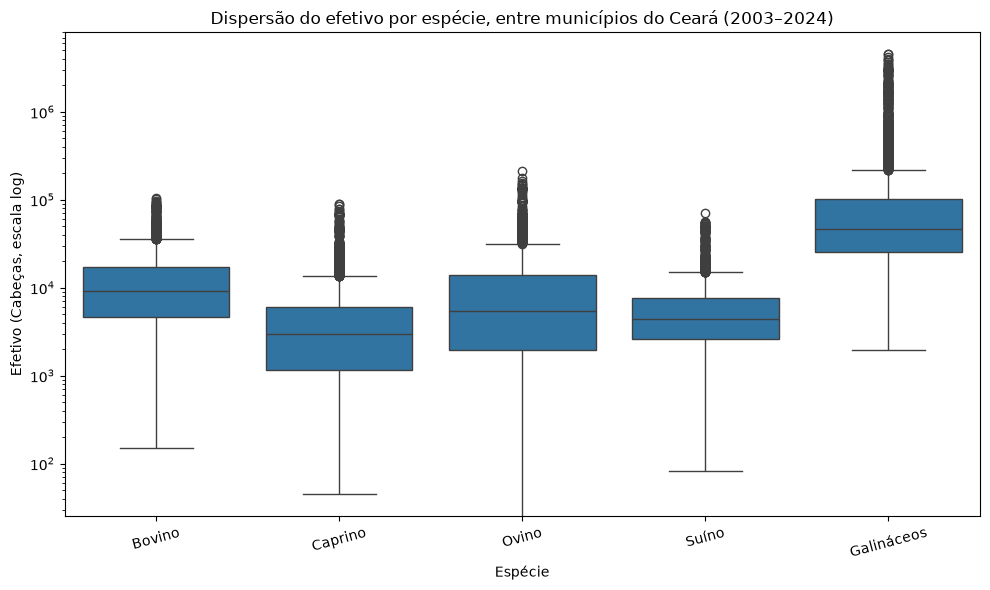

In [64]:
nome_exibicao = {
    "Bovino": "Bovino", "Caprino": "Caprino", "Ovino": "Ovino",
    "Suíno - total": "Suíno", "Galináceos - total": "Galináceos",
}

efetivo_ceara_municipios = df_nome[
    (df_nome['nivel_territorial_nome'] == 'Município') & (df_nome['territorio_nome'].str.endswith('- CE'))
].copy()
efetivo_ceara_municipios['especie'] = efetivo_ceara_municipios['tipo_rebanho_nome'].map(nome_exibicao)

fig, ax = plt.subplots(figsize=(10, 6))
sb.boxplot(data=efetivo_ceara_municipios, x='especie', y='valor', ax=ax)
ax.set_yscale('log')
ax.set_xlabel('Espécie')
ax.set_ylabel('Efetivo (Cabeças, escala log)')
ax.set_title('Dispersão do efetivo por espécie, entre municípios do Ceará (2003–2024)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [65]:
for especie in efetivo_ceara_municipios['tipo_rebanho_nome'].unique():
    serie = efetivo_ceara_municipios[efetivo_ceara_municipios['tipo_rebanho_nome'] == especie]
    valores = serie['valor']
    q1, q3 = valores.quantile([0.25, 0.75])
    cerca_superior = q3 + 1.5 * (q3 - q1)
    n_outliers = (valores > cerca_superior).sum()
    linha_min = serie.loc[valores.idxmin()]
    linha_max = serie.loc[valores.idxmax()]

    print(f"{nome_exibicao[especie]}:")
    print(f"  mínimo: {linha_min['valor']:,.0f} cabeças ({linha_min['territorio_nome']}, {linha_min['ano_nome']})")
    print(f"  mediana: {valores.median():,.0f} cabeças")
    print(f"  máximo: {linha_max['valor']:,.0f} cabeças ({linha_max['territorio_nome']}, {linha_max['ano_nome']})")
    print(f"  cerca superior do boxplot: {cerca_superior:,.0f} cabeças")
    print(f"  outliers acima da cerca: {n_outliers} de {len(valores)} ({n_outliers / len(valores):.1%})")
    print()

Bovino:
  mínimo: 149 cabeças (Guaramiranga - CE, 2017)
  mediana: 9,136 cabeças
  máximo: 104,079 cabeças (Morada Nova - CE, 2024)
  cerca superior do boxplot: 35,809 cabeças
  outliers acima da cerca: 321 de 4048 (7.9%)

Caprino:
  mínimo: 45 cabeças (Acarape - CE, 2003)
  mediana: 2,986 cabeças
  máximo: 90,651 cabeças (Tauá - CE, 2024)
  cerca superior do boxplot: 13,486 cabeças
  outliers acima da cerca: 424 de 4048 (10.5%)

Ovino:
  mínimo: 0 cabeças (Guaramiranga - CE, 2017)
  mediana: 5,442 cabeças
  máximo: 212,758 cabeças (Tauá - CE, 2024)
  cerca superior do boxplot: 31,676 cabeças
  outliers acima da cerca: 376 de 4048 (9.3%)

Suíno:
  mínimo: 83 cabeças (Guaramiranga - CE, 2018)
  mediana: 4,438 cabeças
  máximo: 70,000 cabeças (Ipu - CE, 2015)
  cerca superior do boxplot: 15,106 cabeças
  outliers acima da cerca: 314 de 4048 (7.8%)

Galináceos:
  mínimo: 1,945 cabeças (Fortaleza - CE, 2018)
  mediana: 46,015 cabeças
  máximo: 4,513,278 cabeças (Beberibe - CE, 2023)
  cerc

## Correlação entre Espécies (Ceará)

As espécies se correlacionam entre si na variação % ano a ano? (correlação sobre o crescimento, não soma — e sem o viés de tendência comum que a correlação em nível bruto teria, já que todas cresceram ao longo do período)

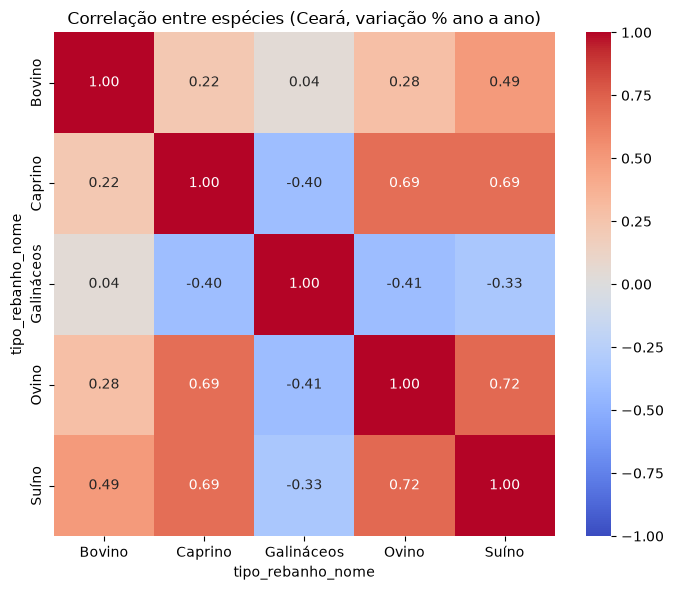

In [66]:
efetivo_ceara_especies = df_nome[df_nome['territorio_nome'] == 'Ceará'].pivot_table(
    index='ano_nome', columns='tipo_rebanho_nome', values='valor'
).rename(columns=nome_exibicao)

correlacao_especies = efetivo_ceara_especies.pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(7, 6))
sb.heatmap(correlacao_especies, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlação entre espécies (Ceará, variação % ano a ano)')
plt.tight_layout()
plt.show()

**Leitura da correlação:** usando variação % ano a ano (não o nível bruto, que ficava inflado pela tendência comum de crescimento das 5 espécies), o quadro é bem diferente:

- **Caprino, Ovino e Suíno (0.69–0.72):** correlacionam moderadamente entre si — quando um cresce mais num ano, os outros tendem a acompanhar. Coerente com serem criações de pequeno porte, muitas vezes no mesmo estabelecimento rural do semiárido.
- **Galináceos × Caprino/Ovino/Suíno (-0.33 a -0.41):** correlação **negativa** — quando os pequenos ruminantes crescem mais num ano, a avicultura tende a crescer menos (ou cair). Faz sentido: avicultura no Ceará é puxada por poucos polos industriais (ex: Beberibe) com ciclo de produção próprio, desligado do calendário de seca/pasto que afeta caprino/ovino/suíno.
- **Bovino:** correlação fraca a moderada com as demais (0.04–0.49) — dinâmica bem própria, não acompanha nem os ruminantes menores nem a avicultura de forma consistente.

Moral: a correlação em nível bruto (0.66–0.97 para tudo) escondia esse contraste — parecia que todas as espécies "andavam juntas", mas na verdade só caprino/ovino/suíno têm relação real ano a ano, e galináceos se move na direção oposta.